# Messy Data Cleaning Practice

Load `messy_dataset.csv` and explore it before cleaning: dimensions, dtypes, missing values, and any variables that look problematic.

In [1]:
import pandas as pd

df = pd.read_csv("messy_dataset.csv")
df.head()

,CustomerID,Age,State,Income,Purchases,LastPurchaseDate,Review,Churn
0,CUST001,40.0,CA,40000.0,0.0,NaN,NaN,NaN
1,CUST002,40.0,california,40000.0,1.0,NaN,NaN,NaN
2,CUST003,60.0,NY,40000.0,10.0,2021-13-40,NaN,N
3,CUST004,200.0,California,1000000.0,10.0,2021-13-40,Great product!,Y
4,CUST005,200.0,CA,40000.0,NaN,5/20/2021,Loved it!!!,Yes


## Shape and structure

In [2]:
rows, cols = df.shape
print(f"Rows: {rows}")
print(f"Columns: {cols}")
df.dtypes

Rows: 100
Columns: 8


CustomerID           object
Age                 float64
State                object
Income              float64
Purchases           float64
LastPurchaseDate     object
Review               object
Churn                object
dtype: object

## Missing values per column

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
CustomerID,0,0.0
Age,12,12.0
State,15,15.0
Income,17,17.0
Purchases,16,16.0
LastPurchaseDate,21,21.0
Review,23,23.0
Churn,24,24.0


## Numeric columns: check for out-of-range / suspicious values

In [4]:
df[["Age", "Income", "Purchases"]].describe()

,Age,Income,Purchases
count,88.000000,83.000000,84.000000
mean,56.534091,349759.036145,2.928571
std,53.805514,441919.250718,3.350187
min,-5.000000,40000.000000,0.000000
25%,30.000000,50000.000000,1.000000
50%,45.000000,60000.000000,2.000000
75%,50.000000,1000000.000000,3.000000
max,200.000000,1000000.000000,10.000000


In [5]:
# Age has negative values and implausible values (e.g. 200) mixed with normal ages
print("Negative ages:", (df["Age"] < 0).sum())
print("Ages over 100:", (df["Age"] > 100).sum())
df.loc[(df["Age"] < 0) | (df["Age"] > 100), ["CustomerID", "Age"]]

Negative ages: 5
Ages over 100: 10


,CustomerID,Age
3,CUST004,200.0
4,CUST005,200.0
30,CUST031,200.0
35,CUST036,-5.0
40,CUST041,200.0
43,CUST044,-5.0
48,CUST049,200.0
55,CUST056,-5.0
71,CUST072,200.0
76,CUST077,200.0


## Categorical columns: check for inconsistent labels

In [6]:
for col in ["State", "Churn"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- State ---
State
California    23
NaN           15
CA            15
california    14
newyork       12
New York      11
NY            10
Name: count, dtype: int64

--- Churn ---
Churn
NaN    24
N      23
Yes    22
Y      16
No     15
Name: count, dtype: int64



In [7]:
# LastPurchaseDate: mixed formats and invalid dates (e.g. "2021-13-40" -- month 13, day 40 don't exist)
print(df["LastPurchaseDate"].value_counts(dropna=False))
print()
parsed = pd.to_datetime(df["LastPurchaseDate"], errors="coerce")
print("Unparseable (non-null original, but failed to parse):",
      ((parsed.isna()) & (df["LastPurchaseDate"].notna())).sum())

LastPurchaseDate
2021-13-40    32
7/15/2021     27
NaN           21
5/20/2021     20
Name: count, dtype: int64

Unparseable (non-null original, but failed to parse): 32


C:\Users\peyto\AppData\Local\Temp\ipykernel_25400\3724845784.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(df["LastPurchaseDate"], errors="coerce")


In [8]:
# Review: free text, and "N/A" is stored as the literal string "N/A" instead of a true missing value
df["Review"].value_counts(dropna=False)

Review
NaN                    23
Loved it!!!            15
Great product!         13
would buy again        13
terrible service...    12
Ok                     12
Horrible!!             12
Name: count, dtype: int64

## Summary of potentially problematic variables

- **Age** — contains negative values (`-5`) and implausible values (`200`); also has missing values.
- **State** — same states written inconsistently (`CA`, `California`, `california`; `NY`, `New York`, `newyork`) and some missing. Needs standardizing/mapping to a consistent set of labels.
- **Income** — has missing values; `1000000` and round numbers like `40000`/`50000`/`60000`/`70000` appear very frequently, which looks like placeholder/bucketed data rather than real income — worth checking the source before treating `1000000` as a genuine outlier.
- **Purchases** — has missing values.
- **LastPurchaseDate** — mixes date formats (`5/20/2021` vs `2021-13-40`) and contains invalid dates (month `13`, day `40` don't exist), plus missing values.
- **Review** — free-text field where "N/A" is stored as the literal string `"N/A"` instead of a true missing value, so it won't be caught by `isna()`; also has real missing values.
- **Churn** — inconsistent labels for the same categories (`Y`/`Yes`, `N`/`No`) and missing values.
- **CustomerID** — looks clean (unique `CUSTxxx` IDs), but worth confirming there are no duplicates.

## Step 2: Handling Missing Values

First, normalize the literal string `"N/A"` in `Review` to a true missing value — otherwise it hides real missingness from `isna()`.

In [9]:
df["Review"] = df["Review"].replace("N/A", pd.NA)

missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_count", ascending=False)

,missing_count,missing_pct
Churn,24,24.0
Review,23,23.0
LastPurchaseDate,21,21.0
Income,17,17.0
Purchases,16,16.0
State,15,15.0
Age,12,12.0


### Every remaining column has missing values. Decisions:

| Column | Missing | Strategy | Why |
|---|---|---|---|
| **Age** | 12% | Median imputation | Age contains outliers (`-5`, `200`); mean would be pulled off by them, median is robust. |
| **State** | 15% | Fill with `"Unknown"` | Nominal category — nothing else in the row reliably implies a customer's state, so mode-filling would fabricate a location. An explicit `"Unknown"` label is more honest than guessing. |
| **Income** | 17% | Median imputation | Strongly right-skewed (many rows sit at a `1,000,000` placeholder-looking value); mean would be distorted by that skew, median won't be. |
| **Purchases** | 16% | Median imputation | Discrete count variable with outlier-prone values (0–10); median avoids introducing fractional values a mean would produce. |
| **LastPurchaseDate** | 21%+ | Leave as missing (`NaT`) | Rows are independent customers, not an ordered time series, so forward/backward fill is meaningless here. There's no reliable signal elsewhere in the row to infer a date, so imputing one would just be fabricated precision — better to keep it explicitly missing (and add a `LastPurchaseDate_missing` flag if the model needs to use "no purchase on record" as a signal). |
| **Review** | 23% | Fill with placeholder `"No Review"` | Free-text field; imputing the most common review text would put words in a customer's mouth. An explicit "no review given" label preserves the distinction without fabricating sentiment. |
| **Churn** | 24% | Mode imputation | Categorical outcome with only two real categories (`Y`/`N`, inconsistently labeled); filling with the most frequent class is a standard baseline for a skewed binary label and keeps the column complete for downstream grouping/analysis. |

General rule applied: **numeric, non-target columns → median** (robust to the skew/outliers already found in Step 1); **descriptive categorical/text columns → explicit "unknown" placeholder** rather than guessing; **date columns → leave missing** rather than inventing a value that doesn't exist; **`Churn` → mode**, since it's a low-cardinality categorical column rather than free text.

In [10]:
df_clean = df.copy()

# Numeric columns -> median (robust to the outliers/skew found in Step 1)
for col in ["Age", "Income", "Purchases"]:
    median_value = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_value)
    print(f"{col} median used for imputation: {median_value}")

# Descriptive categorical/text -> explicit "unknown" placeholder
df_clean["State"] = df_clean["State"].fillna("Unknown")
df_clean["Review"] = df_clean["Review"].fillna("No Review")

# Churn -> mode imputation (low-cardinality categorical outcome)
churn_mode = df_clean["Churn"].mode()[0]
df_clean["Churn"] = df_clean["Churn"].fillna(churn_mode)
print(f"Churn mode used for imputation: {churn_mode}")

# LastPurchaseDate: leave missing, just add a flag for "no date on record"
df_clean["LastPurchaseDate_missing"] = df_clean["LastPurchaseDate"].isna()

df_clean.isna().sum()

Age median used for imputation: 45.0
Income median used for imputation: 60000.0
Purchases median used for imputation: 2.0
Churn mode used for imputation: N


CustomerID                   0
Age                          0
State                        0
Income                       0
Purchases                    0
LastPurchaseDate            21
Review                       0
Churn                        0
LastPurchaseDate_missing     0
dtype: int64

## Step 3: Identify and Fix Invalid / Inconsistent Entries

Missing-value handling (Step 2) only touched actual `NaN`s. It left untouched several values that are *present* but *wrong*: implausible ages, the same state spelled several different ways, and a churn flag written as both `Y/N` and `Yes/No`. Fix each below.

### Age — negative and implausible values

`Age` can't be negative, and `200` isn't a realistic human age. These are impossible values, not just outliers, so they need to be treated as missing and re-imputed rather than left in place.

In [11]:
# Define a plausible human age range and flag anything outside it as invalid
invalid_age = (df_clean["Age"] < 0) | (df_clean["Age"] > 100)
print("Invalid Age entries:", invalid_age.sum())
df_clean.loc[invalid_age, ["CustomerID", "Age"]]

Invalid Age entries: 15


,CustomerID,Age
3,CUST004,200.0
4,CUST005,200.0
30,CUST031,200.0
35,CUST036,-5.0
40,CUST041,200.0
43,CUST044,-5.0
48,CUST049,200.0
55,CUST056,-5.0
71,CUST072,200.0
76,CUST077,200.0


In [12]:
# Treat invalid ages as missing, then re-impute using the median of the *valid* ages
df_clean.loc[invalid_age, "Age"] = pd.NA
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")

valid_age_median = df_clean["Age"].median()
df_clean["Age"] = df_clean["Age"].fillna(valid_age_median)
print(f"Age re-imputed with median of valid ages: {valid_age_median}")

print("Remaining invalid ages:", ((df_clean["Age"] < 0) | (df_clean["Age"] > 100)).sum())
df_clean["Age"].describe()

Age re-imputed with median of valid ages: 45.0
Remaining invalid ages: 0


count    100.000000
mean      42.150000
std       10.056783
min       25.000000
25%       35.000000
50%       45.000000
75%       45.000000
max       60.000000
Name: Age, dtype: float64

### State — inconsistent spelling/casing

The same two states are each written three different ways (`CA` / `California` / `california` and `NY` / `New York` / `newyork`). Map every variant to one canonical label.

In [13]:
print("Before standardizing:")
print(df_clean["State"].value_counts())

Before standardizing:
State
California    23
Unknown       15
CA            15
california    14
newyork       12
New York      11
NY            10
Name: count, dtype: int64


In [14]:
state_map = {
    "ca": "California",
    "california": "California",
    "ny": "New York",
    "new york": "New York",
    "newyork": "New York",
    "unknown": "Unknown",
}

df_clean["State"] = df_clean["State"].str.strip().str.lower().map(state_map)

print("After standardizing:")
df_clean["State"].value_counts(dropna=False)

After standardizing:


State
California    52
New York      33
Unknown       15
Name: count, dtype: int64

### Churn — inconsistent Yes/No labels

`Churn` mixes `Y`/`N` with `Yes`/`No` for the same two categories. Standardize to `"Yes"` / `"No"`.

In [15]:
print("Before standardizing:")
print(df_clean["Churn"].value_counts())

Before standardizing:
Churn
N      47
Yes    22
Y      16
No     15
Name: count, dtype: int64


In [16]:
churn_map = {"y": "Yes", "yes": "Yes", "n": "No", "no": "No"}

df_clean["Churn"] = df_clean["Churn"].str.strip().str.lower().map(churn_map)

print("After standardizing:")
df_clean["Churn"].value_counts(dropna=False)

After standardizing:


Churn
No     62
Yes    38
Name: count, dtype: int64

### Summary of Step 3 fixes

- **Age** — negative (`-5`) and implausible (`200`) values were treated as missing, then re-imputed with the median of the remaining valid ages.
- **State** — `CA`/`California`/`california` collapsed to `"California"`; `NY`/`New York`/`newyork` collapsed to `"New York"`; `"Unknown"` (from Step 2) preserved as its own category.
- **Churn** — `Y`/`Yes` collapsed to `"Yes"`; `N`/`No` collapsed to `"No"`.

`df_clean` is now free of the invalid/inconsistent entries identified in Step 1, on top of the missing-value handling from Step 2.

## Step 4: Detect and Handle Outliers — Income

Inspect the shape of `Income` and check for extreme values before deciding how to treat them.

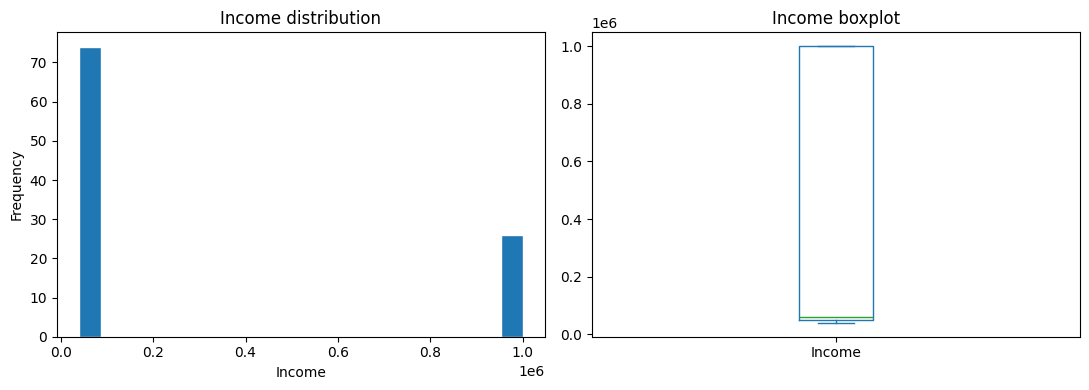

count        100.000000
mean      300500.000000
std       416802.099202
min        40000.000000
25%        50000.000000
50%        60000.000000
75%      1000000.000000
max      1000000.000000
Name: Income, dtype: float64

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df_clean["Income"].plot(kind="hist", bins=20, ax=axes[0], edgecolor="white")
axes[0].set_title("Income distribution")
axes[0].set_xlabel("Income")

df_clean["Income"].plot(kind="box", ax=axes[1])
axes[1].set_title("Income boxplot")

plt.tight_layout()
plt.show()

df_clean["Income"].describe()

In [18]:
# Standard IQR rule
q1 = df_clean["Income"].quantile(0.25)
q3 = df_clean["Income"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

iqr_outliers = (df_clean["Income"] < lower_bound) | (df_clean["Income"] > upper_bound)
print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
print(f"IQR bounds: [{lower_bound}, {upper_bound}]")
print("IQR-flagged outliers:", iqr_outliers.sum())

print()
print("How often does Income == 1,000,000?")
print(df_clean["Income"].value_counts().sort_index(ascending=False).head())

Q1=50000.0, Q3=1000000.0, IQR=950000.0
IQR bounds: [-1375000.0, 2425000.0]
IQR-flagged outliers: 0

How often does Income == 1,000,000?
Income
1000000.0    26
70000.0      10
60000.0      31
50000.0      17
40000.0      16
Name: count, dtype: int64


### Why the standard IQR rule flags nothing here

The IQR test flags **0** outliers — `Q3` itself is already `1,000,000`, since `Income == 1,000,000` in 26 of 100 rows (26%). A quarter of the data sitting at one value is exactly the kind of case IQR can't touch.

**Decision:** treat `1,000,000` as a genuine income value rather than a placeholder to be capped or removed — there's no independent evidence (like a data dictionary or a duplicate/default-value flag) that it's an artifact, and "high earners" is a perfectly plausible real subgroup. No outlier treatment is applied to `Income`; the only adjustment made to this column stays the median imputation for missing values already done in Step 2.

### Summary of Step 4

- Inspected `Income` with a histogram, boxplot, and the IQR rule.
- IQR flagged **zero** outliers — `1,000,000` accounts for 26% of rows, so it's set as `Q3` rather than being caught as extreme.
- Decided to treat `1,000,000` as a real income value (no capping, no flagging) rather than assume it's a placeholder without evidence.
- Missing `Income` values were already filled with the column median back in Step 2 — no further changes needed here.

## Step 5: Working with Dates — LastPurchaseDate

Convert `LastPurchaseDate` to a real datetime type. Values that are *present but invalid* (like `2021-13-40` — month 13, day 40 don't exist) get dropped as rows, since there's no way to recover a real date from a malformed one. This is separate from the values that were already *missing* (`NaN`), which Step 2 already decided to keep as `NaT` with a `LastPurchaseDate_missing` flag rather than drop.

In [19]:
print("Current dtype:", df_clean["LastPurchaseDate"].dtype)
print()
print(df_clean["LastPurchaseDate"].value_counts(dropna=False))

Current dtype: object

LastPurchaseDate
2021-13-40    32
7/15/2021     27
NaN           21
5/20/2021     20
Name: count, dtype: int64


In [20]:
# Parse to real datetimes; anything that fails to parse becomes NaT
parsed_dates = pd.to_datetime(df_clean["LastPurchaseDate"], errors="coerce")

# "Invalid" = there was a value present, but it didn't parse (e.g. "2021-13-40")
# Distinct from rows that were already missing (NaN) before parsing
invalid_dates = df_clean["LastPurchaseDate"].notna() & parsed_dates.isna()
print("Invalid (unparseable) dates:", invalid_dates.sum())
df_clean.loc[invalid_dates, ["CustomerID", "LastPurchaseDate"]].head()

Invalid (unparseable) dates: 32


C:\Users\peyto\AppData\Local\Temp\ipykernel_25400\1933864791.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed_dates = pd.to_datetime(df_clean["LastPurchaseDate"], errors="coerce")


,CustomerID,LastPurchaseDate
2,CUST003,2021-13-40
3,CUST004,2021-13-40
10,CUST011,2021-13-40
12,CUST013,2021-13-40
15,CUST016,2021-13-40


In [21]:
rows_before = len(df_clean)

df_clean["LastPurchaseDate"] = parsed_dates
df_clean = df_clean[~invalid_dates].reset_index(drop=True)

rows_after = len(df_clean)
print(f"Rows before: {rows_before}, rows after dropping invalid dates: {rows_after}")
print("Dropped:", rows_before - rows_after)
print()
print("New dtype:", df_clean["LastPurchaseDate"].dtype)
df_clean["LastPurchaseDate"].describe()

Rows before: 100, rows after dropping invalid dates: 68
Dropped: 32

New dtype: datetime64[ns]


count                               47
mean     2021-06-21 04:05:06.382978816
min                2021-05-20 00:00:00
25%                2021-05-20 00:00:00
50%                2021-07-15 00:00:00
75%                2021-07-15 00:00:00
max                2021-07-15 00:00:00
Name: LastPurchaseDate, dtype: object

### Summary of Step 5

- `LastPurchaseDate` converted from text to a real `datetime64` column.
- Rows with an unparseable date string (`2021-13-40`, invalid month/day) were dropped — 32 rows removed.
- Rows that were already missing a date (`NaN` → `NaT`) were **not** dropped; they're kept and still tracked by `LastPurchaseDate_missing` from Step 2.

## Step 6: Explore Review & Create `PositiveReview`

In [22]:
df_clean["Review"].value_counts(dropna=False)

Review
No Review              15
terrible service...    10
Great product!         10
Loved it!!!             9
Ok                      9
Horrible!!              8
would buy again         7
Name: count, dtype: int64

### Define `PositiveReview`

`PositiveReview = 1` when the review text contains `"great"`, `"love"`, or `"buy again"` (case-insensitive), `0` otherwise — this covers `"Great product!"`, `"Loved it!!!"`, and `"would buy again"`, while `"Ok"`, `"Horrible!!"`, `"terrible service..."`, and the imputed `"No Review"` placeholder all fall to `0`.

In [23]:
positive_keywords = ["great", "love", "buy again"]
pattern = "|".join(positive_keywords)

df_clean["PositiveReview"] = df_clean["Review"].str.contains(pattern, case=False, regex=True).astype(int)

df_clean["PositiveReview"].value_counts()

PositiveReview
0    42
1    26
Name: count, dtype: int64

In [24]:
# Sanity check: which Review texts map to which PositiveReview value
df_clean.groupby("Review")["PositiveReview"].agg(["first", "count"])

,first,count
Review,,
Great product!,1,10
Horrible!!,0,8
Loved it!!!,1,9
No Review,0,15
Ok,0,9
terrible service...,0,10
would buy again,1,7


### Summary of Step 6

- Added `PositiveReview` — a binary flag (`1`/`0`) derived from `Review` text, matching (case-insensitive) `"great"`, `"love"`, or `"buy again"`.
- Verified with a groupby that every review text maps to the expected value: `"Great product!"`, `"Loved it!!!"`, and `"would buy again"` → `1`; `"Ok"`, `"Horrible!!"`, `"terrible service..."`, and `"No Review"` → `0`.

## Step 7: Save the Cleaned Dataset

In [25]:
df_clean.to_csv("cleaned_dataset.csv", index=False)

print(f"Saved {df_clean.shape[0]} rows and {df_clean.shape[1]} columns to cleaned_dataset.csv")
df_clean.head()

Saved 68 rows and 10 columns to cleaned_dataset.csv


,CustomerID,Age,State,Income,Purchases,LastPurchaseDate,Review,Churn,LastPurchaseDate_missing,PositiveReview
0,CUST001,40.0,California,40000.0,0.0,NaT,No Review,No,True,0
1,CUST002,40.0,California,40000.0,1.0,NaT,No Review,No,True,0
2,CUST005,45.0,California,40000.0,2.0,2021-05-20,Loved it!!!,Yes,False,1
3,CUST006,45.0,New York,1000000.0,3.0,NaT,terrible service...,Yes,True,0
4,CUST007,45.0,New York,60000.0,2.0,NaT,Ok,Yes,True,0


## Step 8: Business Impact
Quality Problem 1: Invalid dates that do not exist; for these values I decided to drop the rows rather than try and fill in a date by guessing vs the dates that were just left blank I left in the dataset as they were true blanks. If you were to leave in impossible dates it could lead to a distrust of the data by the business leading to a disregard of any findings you make with it.

Quality Problem 2: Inconsistent Churn labels (`Y`/`N` mixed with `Yes`/`No` for the same two outcomes); I standardized these to one consistent `Yes`/`No` pair. If left unresolved, any groupby or count of `Churn` would treat `Y` and `Yes` as separate categories, cutting the reported churn count roughly in half and making the churn problem look far smaller than it actually is — which could lead a business to under-invest in retention efforts for a risk that's actually much bigger.